Builds the statistical distribution json required for the Main Generator

---



In [ ]:
# each object where "#" = v# needs
#  sample size
#  mean + std + percentiles
#   difficulty_numeric
#   range_x
#   range_y
#   horizontal_start_to_finish
#   vertical_start_to_finish
#   euclidean_start_to_finish
#  discrete distribution (e.g. 1: 0.3, 2: 0.55, 4: 0.15) of...
#   # total holds
#   # start, regular, foot, finish
#   # placementId for each start, regular, foot, finish
#   # joint role count
#   angles

In [ ]:
# how this is used in the context of the generator:
# generator gets v grade, refers to the json created by this code.
# generates random climbs based on the statistics of the json
# first check: is the climb impossible (0 start/finish, duplicate placement, invalid id)?
# second check: use regression model; is difficulty_numeric outside of range?
# both checks mean climb is good, add it to candidate list
# repeat until 100 in list, then pick the one closest to difficulty_numeric mean

In [ ]:
!pip -q install huggingface_hub

In [ ]:
from pathlib import Path
from huggingface_hub import hf_hub_download

DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(exist_ok=True)

DB_PATH = hf_hub_download(
    repo_id="Vilin97/KilterBoard",
    filename="kilter_splits.sqlite",
    repo_type="dataset",
    local_dir=str(DATA_DIR),
)

print("Downloaded DB to:", DB_PATH)

Downloaded DB to: /content/data/kilter_splits.sqlite


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(DB_PATH)

difficulty_bands = [10, 12.5, 14.5, 15.4628, 17.4742, 19.4829, 21.4706, 22.5000, 23.4762, 25.4915, 26.5000, 27.4706, 28.5000, 29.4444]

for i in range(len(difficulty_bands) - 1):
    min_diff = difficulty_bands[i]
    max_diff = difficulty_bands[i+1]

    query = f"""
    SELECT *
    FROM kilter_train
    WHERE (difficulty_numeric >= {min_diff} AND difficulty_numeric <= {max_diff})
    AND layout_id = 1
    """

    # Load the filtered data directly into a pandas DataFrame
    filtered_df = pd.read_sql_query(query, conn)

    # Save the dataframe to a new CSV file
    filename = f"v{i}.csv"
    filtered_df.to_csv(filename, index=False)

    print(f"Created {filename} with {len(filtered_df)} rows for difficulty range {min_diff} to {max_diff}.")

Created v0.csv with 10516 rows for difficulty range 10 to 12.5.
Created v1.csv with 11790 rows for difficulty range 12.5 to 14.5.
Created v2.csv with 10856 rows for difficulty range 14.5 to 15.4628.
Created v3.csv with 26385 rows for difficulty range 15.4628 to 17.4742.
Created v4.csv with 30962 rows for difficulty range 17.4742 to 19.4829.
Created v5.csv with 32668 rows for difficulty range 19.4829 to 21.4706.
Created v6.csv with 22011 rows for difficulty range 21.4706 to 22.5.
Created v7.csv with 17607 rows for difficulty range 22.5 to 23.4762.
Created v8.csv with 18022 rows for difficulty range 23.4762 to 25.4915.
Created v9.csv with 5895 rows for difficulty range 25.4915 to 26.5.
Created v10.csv with 3285 rows for difficulty range 26.5 to 27.4706.
Created v11.csv with 1562 rows for difficulty range 27.4706 to 28.5.
Created v12.csv with 607 rows for difficulty range 28.5 to 29.4444.


In [ ]:
import json
import re
import os
import numpy as np

def process_v_grade(grade_level):
    """
    Processes the v#.csv file for a given grade level, calculates statistics,
    and updates the corresponding v#_stats.json file.
    """
    csv_filename = f'v{grade_level}.csv'
    json_filename = f'v{grade_level}_stats.json'

    if not os.path.exists(csv_filename):
        print(f"File {csv_filename} not found. Skipping.")
        return

    # Load the data
    df = pd.read_csv(csv_filename)
    print(f"Processing {csv_filename} with {len(df)} rows...")

    # Calculate ranges
    df['range_x'] = df['edge_right'] - df['edge_left']
    df['range_y'] = df['edge_top'] - df['edge_bottom']

    # Function to calculate start to finish distances
    def calc_distances(frames_xy):
        try:
            if pd.isna(frames_xy):
                return pd.Series({"h_dist": np.nan, "v_dist": np.nan, "e_dist": np.nan})

            # Find all Start and Finish coordinates
            starts = re.findall(r'\((\d+),(\d+)\)S', frames_xy)
            finishes = re.findall(r'\((\d+),(\d+)\)[ET]', frames_xy)

            if not starts or not finishes:
                return pd.Series({"h_dist": np.nan, "v_dist": np.nan, "e_dist": np.nan})

            start_xs = [int(x) for x, y in starts]
            start_ys = [int(y) for x, y in starts]
            finish_xs = [int(x) for x, y in finishes]
            finish_ys = [int(y) for x, y in finishes]

            # Use the mean coordinate if there are multiple start/finish holds
            mean_start_x, mean_start_y = np.mean(start_xs), np.mean(start_ys)
            mean_finish_x, mean_finish_y = np.mean(finish_xs), np.mean(finish_ys)

            dx = abs(mean_finish_x - mean_start_x)
            dy = abs(mean_finish_y - mean_start_y)
            dist = np.sqrt(dx**2 + dy**2)

            return pd.Series({"h_dist": dx, "v_dist": dy, "e_dist": dist})
        except:
            return pd.Series({"h_dist": np.nan, "v_dist": np.nan, "e_dist": np.nan})

    # Apply distance calculations
    dists = df['frames_xy'].apply(calc_distances)
    h_dist_clean = dists['h_dist'].dropna()
    v_dist_clean = dists['v_dist'].dropna()
    e_dist_clean = dists['e_dist'].dropna()

    # Helper to convert series/lists to discrete distributions dicts
    def get_dist(data):
        if isinstance(data, pd.Series):
            counts = data.value_counts(normalize=True)
        else:
            counts = pd.Series(data).value_counts(normalize=True)
        return {str(k): float(v) for k, v in counts.items()}

    # Helper for percentiles
    def get_percentiles(s):
        if len(s) == 0:
            return {'mean': 0.0, 'std': 0.0, 'p05': 0.0, 'p25': 0.0, 'p50': 0.0, 'p75': 0.0, 'p95': 0.0}
        return {
            'mean': float(s.mean()),
            'std': float(s.std()),
            'p05': float(s.quantile(0.05)),
            'p25': float(s.quantile(0.25)),
            'p50': float(s.quantile(0.50)),
            'p75': float(s.quantile(0.75)),
            'p95': float(s.quantile(0.95))
        }

    # Parse frames for roles and placements
    role_counts_list = {12: [], 13: [], 14: [], 15: []}
    placements_list = {12: [], 13: [], 14: [], 15: []}
    joint_roles = []

    parsed_frames = df['frames'].apply(lambda x: re.findall(r'p(\d+)r(\d+)', str(x)) if pd.notna(x) else [])

    for frames in parsed_frames:
        counts = {12: 0, 13: 0, 14: 0, 15: 0}
        for p, r in frames:
            p, r = int(p), int(r)
            if r in counts:
                counts[r] += 1
                placements_list[r].append(p)

        for r in [12, 13, 14, 15]:
            role_counts_list[r].append(counts[r])

        # Format: Start-Regular-Foot-Finish counts
        joint_roles.append(f"{counts[12]}-{counts[13]}-{counts[15]}-{counts[14]}")

    # Filter and Renormalize joint_role_dist
    joint_role_dist = get_dist(joint_roles)
    joint_role_dist = {k: v for k, v in joint_role_dist.items() if v >= 0.001}
    total_j_prob = sum(joint_role_dist.values())
    if total_j_prob > 0:
        joint_role_dist = {k: v / total_j_prob for k, v in joint_role_dist.items()}

    # Initialize stats dictionary
    grade_key = f"v{grade_level}"
    stats = {
        grade_key: {
            "sample_size": int(len(df)),
            "difficulty_numeric": get_percentiles(df['difficulty_numeric']),
            "range_x": get_percentiles(df['range_x']),
            "range_y": get_percentiles(df['range_y']),
            "horizontal_start_to_finish": get_percentiles(h_dist_clean),
            "vertical_start_to_finish": get_percentiles(v_dist_clean),
            "euclidean_start_to_finish": get_percentiles(e_dist_clean),
            "discrete_distributions": {
                "num_holds": get_dist(df['num_holds']),
                "angles": get_dist(df['angle']),
                "role_counts": {
                    "start": get_dist(role_counts_list[12]),
                    "regular": get_dist(role_counts_list[13]),
                    "foot": get_dist(role_counts_list[15]),
                    "finish": get_dist(role_counts_list[14])
                },
                "placement_ids": {
                    "start": get_dist(placements_list[12]),
                    "regular": get_dist(placements_list[13]),
                    "foot": get_dist(placements_list[15]),
                    "finish": get_dist(placements_list[14])
                },
                "joint_role_count": joint_role_dist
            }
        }
    }

    # Write JSON
    with open(json_filename, 'w') as f:
        json.dump(stats, f, indent=4)

    print(f"Finished processing and saved to {json_filename}\n")

# Process all files
for i in range(13):
    process_v_grade(i)


Processing v0.csv with 10516 rows...
Finished processing and saved to v0_stats.json

Processing v1.csv with 11790 rows...
Finished processing and saved to v1_stats.json

Processing v2.csv with 10856 rows...
Finished processing and saved to v2_stats.json

Processing v3.csv with 26385 rows...
Finished processing and saved to v3_stats.json

Processing v4.csv with 30962 rows...
Finished processing and saved to v4_stats.json

Processing v5.csv with 32668 rows...
Finished processing and saved to v5_stats.json

Processing v6.csv with 22011 rows...
Finished processing and saved to v6_stats.json

Processing v7.csv with 17607 rows...
Finished processing and saved to v7_stats.json

Processing v8.csv with 18022 rows...
Finished processing and saved to v8_stats.json

Processing v9.csv with 5895 rows...
Finished processing and saved to v9_stats.json

Processing v10.csv with 3285 rows...
Finished processing and saved to v10_stats.json

Processing v11.csv with 1562 rows...
Finished processing and save

In [ ]:
# Start final combined file with metadata
combined_stats = {
    "metadata": {
        "joint_role_count_format": "start-regular-foot-finish",
        "placement_id_type": "kilter_placement_id",
        "generated_from_split": "train"
    }
}

# Iterate through all possible grade files and merge them
for i in range(13):
    filename = f'v{i}_stats.json'
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            grade_data = json.load(f)
            # Each file contains a single top-level key like "v0", "v1", etc.
            combined_stats.update(grade_data)

# Save the combined statistics to a single file
output_filename = 'GeneratorStats.json'
with open(output_filename, 'w') as f:
    json.dump(combined_stats, f, indent=4)

print(f"Successfully merged all stats into {output_filename}")
# Display the top-level keys to confirm structure
print("Top-level keys:", list(combined_stats.keys()))

Successfully merged all stats into GeneratorStats.json
Top-level keys: ['metadata', 'v0', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12']


fun visualizations for the readme

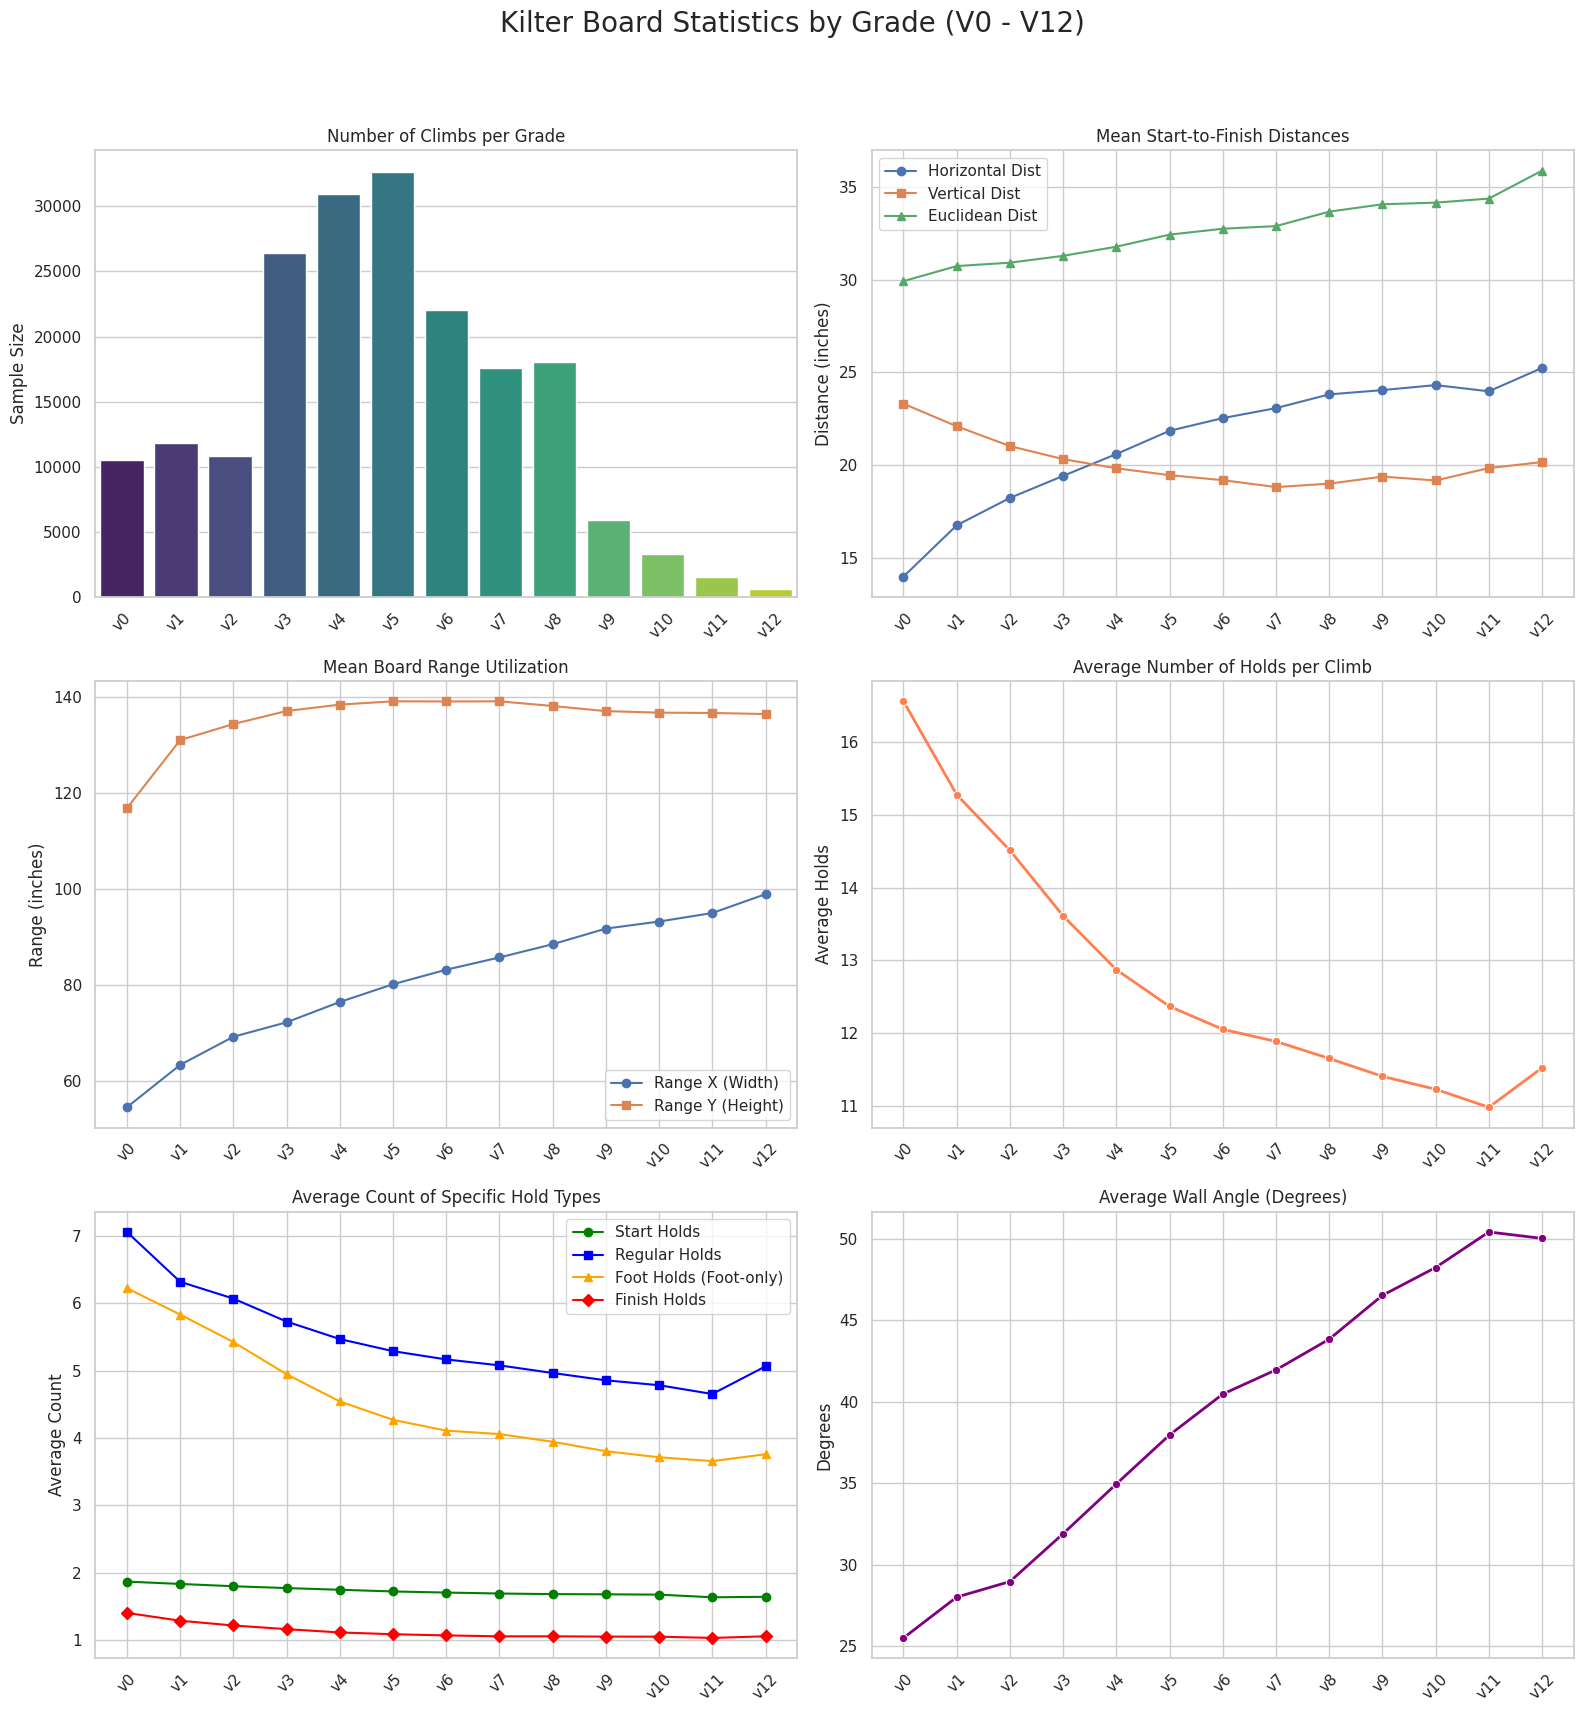

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the combined stats
with open('GeneratorStats.json', 'r') as f:
    stats_data = json.load(f)

# Extract grades and sort them numerically
grades = [f'v{i}' for i in range(13)]

# Prepare data for plotting
sample_sizes = []
mean_h_dist = []
mean_v_dist = []
mean_e_dist = []
mean_range_x = []
mean_range_y = []
avg_num_holds = []
avg_starts = []
avg_regulars = []
avg_foots = []
avg_finishes = []
avg_angles = []

def get_expected_value(dist_dict):
    return sum(float(k) * float(v) for k, v in dist_dict.items())

for g in grades:
    data = stats_data[g]
    sample_sizes.append(data['sample_size'])
    mean_h_dist.append(data['horizontal_start_to_finish']['mean'])
    mean_v_dist.append(data['vertical_start_to_finish']['mean'])
    mean_e_dist.append(data['euclidean_start_to_finish']['mean'])
    mean_range_x.append(data['range_x']['mean'])
    mean_range_y.append(data['range_y']['mean'])

    dist = data['discrete_distributions']

    # Calculate expected values from discrete distributions
    avg_num_holds.append(get_expected_value(dist['num_holds']))
    avg_starts.append(get_expected_value(dist['role_counts']['start']))
    avg_regulars.append(get_expected_value(dist['role_counts']['regular']))
    avg_foots.append(get_expected_value(dist['role_counts']['foot']))
    avg_finishes.append(get_expected_value(dist['role_counts']['finish']))
    avg_angles.append(get_expected_value(dist['angles']))

# Set plotting style
sns.set_theme(style="whitegrid")

# Create subplots in a 3x2 grid
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Kilter Board Statistics by Grade (V0 - V12)', fontsize=20)

# Plot 1: Sample Sizes
sns.barplot(x=grades, y=sample_sizes, ax=axes[0, 0], hue=grades, palette="viridis", legend=False)
axes[0, 0].set_title('Number of Climbs per Grade')
axes[0, 0].set_ylabel('Sample Size')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Distances
axes[0, 1].plot(grades, mean_h_dist, marker='o', label='Horizontal Dist')
axes[0, 1].plot(grades, mean_v_dist, marker='s', label='Vertical Dist')
axes[0, 1].plot(grades, mean_e_dist, marker='^', label='Euclidean Dist')
axes[0, 1].set_title('Mean Start-to-Finish Distances')
axes[0, 1].set_ylabel('Distance (inches)')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Board Range
axes[1, 0].plot(grades, mean_range_x, marker='o', label='Range X (Width)')
axes[1, 0].plot(grades, mean_range_y, marker='s', label='Range Y (Height)')
axes[1, 0].set_title('Mean Board Range Utilization')
axes[1, 0].set_ylabel('Range (inches)')
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Average Number of Holds
sns.lineplot(x=grades, y=avg_num_holds, marker='o', ax=axes[1, 1], color='coral', linewidth=2)
axes[1, 1].set_title('Average Number of Holds per Climb')
axes[1, 1].set_ylabel('Average Holds')
axes[1, 1].tick_params(axis='x', rotation=45)

# Plot 5: Breakdown of Hold Types
axes[2, 0].plot(grades, avg_starts, marker='o', label='Start Holds', color='green')
axes[2, 0].plot(grades, avg_regulars, marker='s', label='Regular Holds', color='blue')
axes[2, 0].plot(grades, avg_foots, marker='^', label='Foot Holds (Foot-only)', color='orange')
axes[2, 0].plot(grades, avg_finishes, marker='D', label='Finish Holds', color='red')
axes[2, 0].set_title('Average Count of Specific Hold Types')
axes[2, 0].set_ylabel('Average Count')
axes[2, 0].legend()
axes[2, 0].tick_params(axis='x', rotation=45)

# Plot 6: Average Angle
sns.lineplot(x=grades, y=avg_angles, marker='o', ax=axes[2, 1], color='purple', linewidth=2)
axes[2, 1].set_title('Average Wall Angle (Degrees)')
axes[2, 1].set_ylabel('Degrees')
axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()